# Preparação dos Dados e Engenharia de Métricas

Este notebook apresenta a etapa de preparação dos dados utilizada no projeto "Recomendador Personalizado de Estudos".

O objetivo desta etapa é realizar o carregamento, limpeza e organização do dataset, além da criação de métricas que serão utilizadas posteriormente pelo sistema de recomendação e pelos modelos de Inteligência Artificial.

In [2]:
%pip install pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 24.5 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 44.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 24.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 37.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 41.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para manipulação e análise dos dados.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carregamento do dataset

O dataset utilizado contém informações relacionadas ao desempenho dos estudantes em exercícios educacionais, incluindo taxa de acerto, quantidade de tentativas, tempo de resposta e uso de dicas.

In [4]:
df = pd.read_csv("../dataset/sample.csv")

In [5]:
df.head()

,problem_log_id,skill,problem_id,user_id,assignment_id,assistment_id,start_time,end_time,problem_type,original,...,overlap_time,template_id,answer_id,answer_text,first_action,problemlogid,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
0,142256246,Conversion of Fraction Decimals Percents,85832,126240,649789,47314,2013-03-05 13:33:08,2013-03-05 13:33:23.517,algebra,1,...,15502,29869,NaN,13/100,0,142256246,0.361323,0.000000,0.766925,0.000000
1,145557895,NaN,437124,220219,539600,255713,2013-06-27 12:19:51,2013-06-27 12:20:06.231,choose_1,1,...,15169,255713,NaN,D. Wind speed,0,145557895,0.361323,0.000000,0.766925,0.000000
2,142795456,NaN,190212,179178,720861,99642,2013-03-26 12:02:41,2013-03-26 12:03:05.482,algebra,1,...,24471,99142,NaN,2/1,0,142795456,0.361323,0.000000,0.766925,0.697987
3,140415576,NaN,508123,182030,647492,303910,2012-12-19 13:50:02,2012-12-19 13:50:14.51,choose_1,1,...,12423,303910,NaN,inequality,0,140415576,0.361323,0.000000,0.766925,0.912281
4,138589431,Addition and Subtraction Positive Decimals,365958,155793,586953,204020,2012-10-22 11:45:23,2012-10-22 11:46:19.767,algebra,1,...,56748,204020,NaN,259.762,0,138589431,0.361323,0.984127,0.766925,0.762689


## Verificação das colunas do dataset

Nesta etapa são verificadas as colunas disponíveis no conjunto de dados para identificar quais atributos serão utilizados na análise e na construção das métricas.

In [6]:
df.columns

Index(['problem_log_id', 'skill', 'problem_id', 'user_id', 'assignment_id',
       'assistment_id', 'start_time', 'end_time', 'problem_type', 'original',
       'correct', 'bottom_hint', 'hint_count', 'actions', 'attempt_count',
       'ms_first_response', 'tutor_mode', 'sequence_id', 'student_class_id',
       'position', 'type', 'base_sequence_id', 'skill_id', 'teacher_id',
       'school_id', 'overlap_time', 'template_id', 'answer_id', 'answer_text',
       'first_action', 'problemlogid', 'Average_confidence(FRUSTRATED)',
       'Average_confidence(CONFUSED)', 'Average_confidence(CONCENTRATING)',
       'Average_confidence(BORED)'],
      dtype='str')

## Verificação de valores ausentes

Nesta etapa é realizada a verificação de valores nulos no dataset, permitindo identificar possíveis problemas de preenchimento que possam impactar as análises e os modelos de recomendação.

In [7]:
df.isnull().sum()

problem_log_id                           0
skill                                34687
problem_id                               0
user_id                                  0
assignment_id                            0
assistment_id                            0
start_time                               0
end_time                                 0
problem_type                             0
original                                 0
correct                                  0
bottom_hint                            573
hint_count                               0
actions                                  0
attempt_count                            0
ms_first_response                        0
tutor_mode                               0
sequence_id                              0
student_class_id                         0
position                                 0
type                                     0
base_sequence_id                         0
skill_id                             33859
teacher_id 

## Limpeza dos dados

Para garantir maior consistência na análise, foram removidas as linhas que não possuem informação de habilidade ("skill"), já que essa coluna é essencial para o sistema de recomendação personalizado.

In [8]:
df = df.dropna(subset=["skill"])

## Criação de métricas por habilidade

Nesta etapa são criadas métricas agregadas por habilidade ("skill"), permitindo identificar padrões de dificuldade, desempenho e comportamento dos estudantes.

### Taxa média de acerto por habilidade

A taxa de acerto permite identificar quais habilidades apresentam maior facilidade ou dificuldade para os estudantes.

In [9]:
skill_accuracy = df.groupby("skill")["correct"].mean()

skill_accuracy.head()

skill
Absolute Value                        0.703704
Addition Mixed Fractions              0.222222
Addition Proper Fractions             0.500000
Addition Whole Numbers                0.859155
Addition and Subtraction Fractions    0.694314
Name: correct, dtype: float64

### Média de tentativas por habilidade

A quantidade média de tentativas pode indicar dificuldades de aprendizado em determinados conteúdos.

In [10]:
skill_attempts = df.groupby("skill")["attempt_count"].mean()

skill_attempts.head()

skill
Absolute Value                        1.348148
Addition Mixed Fractions              1.000000
Addition Proper Fractions             1.000000
Addition Whole Numbers                1.253521
Addition and Subtraction Fractions    1.440803
Name: attempt_count, dtype: float64

### Média de uso de dicas por habilidade

O uso de dicas auxilia na identificação de conteúdos em que os estudantes necessitam de maior suporte.

In [11]:
skill_hints = df.groupby("skill")["hint_count"].mean()

skill_hints.head()

skill
Absolute Value                        0.192593
Addition Mixed Fractions              0.000000
Addition Proper Fractions             0.000000
Addition Whole Numbers                0.098592
Addition and Subtraction Fractions    0.531773
Name: hint_count, dtype: float64

### Tempo médio de resposta por habilidade

O tempo médio de resposta pode indicar níveis de dificuldade ou maior esforço cognitivo em determinados conteúdos.

In [12]:
skill_time = df.groupby("skill")["ms_first_response"].mean()

skill_time.head()

skill
Absolute Value                         24110.355556
Addition Mixed Fractions              134799.555556
Addition Proper Fractions              54925.750000
Addition Whole Numbers                 38894.633803
Addition and Subtraction Fractions     78599.920401
Name: ms_first_response, dtype: float64

## Criação do score de dificuldade

Foi criado um score de dificuldade combinando diferentes métricas, como:
- taxa de acerto
- quantidade de tentativas
- uso de dicas

O objetivo é identificar quais habilidades apresentam maior dificuldade para os estudantes.

In [13]:
difficulty_score = (
    (1 - skill_accuracy) +
    (skill_attempts / skill_attempts.max()) +
    (skill_hints / skill_hints.max())
) / 3

In [14]:
difficulty_score.sort_values(ascending=False).head(10)

skill
Transformation                                   0.979167
Solving System of Equation                       0.777778
Quadratic Formula to Solve Quadratic Equation    0.677083
Write Linear Equation from Ordered Pairs         0.676502
Surface Area Pyramid                             0.656250
Combining Like Terms                             0.583543
Properties and Clasification of Pyramid          0.583333
Volume Cone                                      0.573129
Surface Area Cylinder                            0.567515
Percents                                         0.555556
dtype: float64

## Consolidação das métricas

As métricas calculadas foram organizadas em um único dataframe para facilitar o uso posterior nos modelos de recomendação e aprendizado de máquina.

In [15]:
metrics_df = pd.DataFrame({
    "accuracy": skill_accuracy,
    "attempts": skill_attempts,
    "hints": skill_hints,
    "response_time": skill_time,
    "difficulty_score": difficulty_score
})

metrics_df.head()

,accuracy,attempts,hints,response_time,difficulty_score
skill,,,,,
Absolute Value,0.703704,1.348148,0.192593,24110.355556,0.299383
Addition Mixed Fractions,0.222222,1.000000,0.000000,134799.555556,0.384259
Addition Proper Fractions,0.500000,1.000000,0.000000,54925.750000,0.291667
Addition Whole Numbers,0.859155,1.253521,0.098592,38894.633803,0.220070
Addition and Subtraction Fractions,0.694314,1.440803,0.531773,78599.920401,0.370624


## Exportação dos dados processados

Por fim, o conjunto de métricas gerado foi exportado para um arquivo CSV, permitindo sua utilização nas próximas etapas do projeto.

In [16]:
metrics_df.to_csv("../dataset/processed_metrics.csv")

## Visualização das habilidades mais difíceis

O gráfico abaixo apresenta as habilidades com maior score de dificuldade calculado a partir das métricas de desempenho dos estudantes.

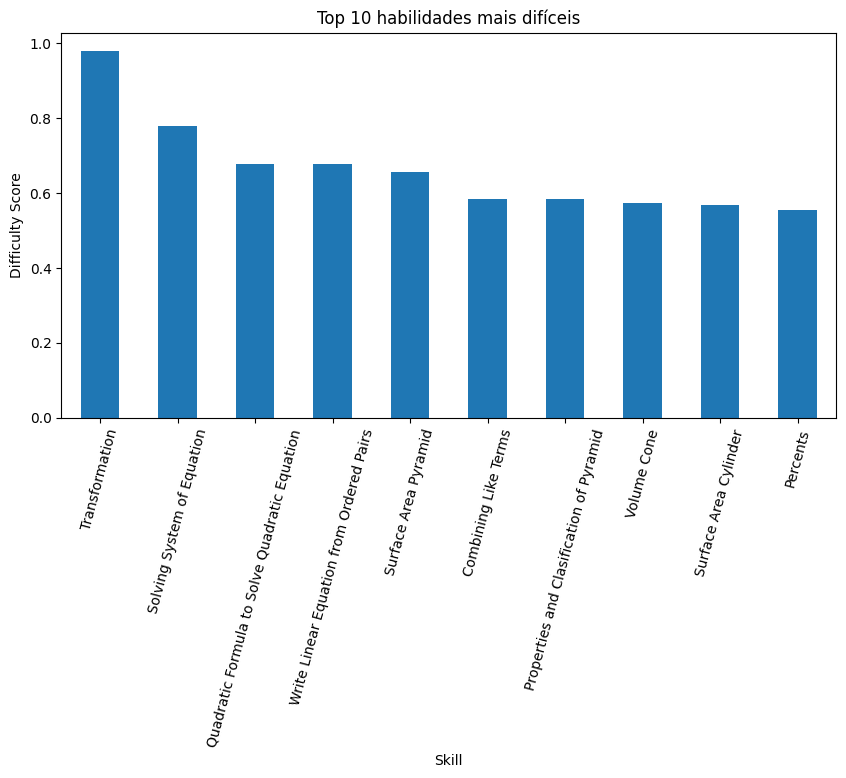

In [20]:
top_difficult = difficulty_score.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_difficult.plot(kind='bar')

plt.title("Top 10 habilidades mais difíceis")
plt.ylabel("Difficulty Score")
plt.xlabel("Skill")

plt.xticks(rotation=75)

plt.show()

## Considerações finais

A etapa de preparação dos dados permitiu organizar, limpar e transformar o dataset original em informações relevantes para a construção do sistema de recomendação personalizado.

Além da criação de métricas relacionadas ao desempenho dos estudantes, também foi desenvolvido um score de dificuldade capaz de identificar habilidades com maior nível de complexidade e dificuldade de aprendizado.

Os resultados obtidos, incluindo as visualizações gráficas geradas, contribuem para uma melhor compreensão do comportamento dos estudantes e servirão como base para as próximas etapas de modelagem e recomendação do projeto.